# 🎓 Study Session 5 — Feature Importance & Model Refinement

## Goals
1. Review multicollinearity (VIF) and remove redundant predictors.  
2. Learn how to extract and visualize **feature importance** from regression models.  
3. Explore **regularization techniques**:
   - Ridge (L2) and Lasso (L1) regression.  
   - Understand how they handle correlated features.  
4. Compare model performance using **Adjusted R²**, **RMSE**, and **cross-validation**.  
5. Interpret coefficients and penalties in plain English (ELI5).  
6. Generate and log updated visualizations with `save_and_log_plot()`.

---

**Starting Dataset:**  
`df` with columns  
`bill_total_usd`, `tip_usd`, `party_size`, `gender_Male`, `is_smoker_Yes`

**Expected Outcome:**  
A cleaner, more interpretable model that balances accuracy and simplicity.


#### create Study_Session_5_Checklist.pdf

In [8]:
# # make_session5_checklist.py
# # Generate "Study Session 5 — Feature Importance & Model Refinement" checklist PDF

# from pathlib import Path
# from datetime import datetime

# from reportlab.lib.pagesizes import letter
# from reportlab.lib import colors
# from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
# from reportlab.platypus import (
#     SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, HRFlowable
# )
# from reportlab.pdfbase import pdfmetrics
# from reportlab.pdfbase.ttfonts import TTFont


# def build_session5_checklist(out_path: Path):
#     """Create the Study Session 5 checklist PDF."""
#     out_path.parent.mkdir(parents=True, exist_ok=True)

#     # Try a nice Unicode font; fall back if not available
#     try:
#         pdfmetrics.registerFont(
#             TTFont("DejaVuSans", "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf")
#         )
#         base_font = "DejaVuSans"
#     except Exception:
#         base_font = "Helvetica"

#     styles = getSampleStyleSheet()
#     title_style  = ParagraphStyle("TitleLarge", parent=styles["Title"],
#                                   fontName=base_font, fontSize=22, leading=26, spaceAfter=12)
#     sub_style    = ParagraphStyle("Subtle", parent=styles["Normal"],
#                                   fontName=base_font, fontSize=10.5, textColor=colors.grey, spaceAfter=8)
#     header_style = ParagraphStyle("Header", parent=styles["Heading2"],
#                                   fontName=base_font, fontSize=14, spaceBefore=8, spaceAfter=6)
#     item_style   = ParagraphStyle("Item", parent=styles["Normal"],
#                                   fontName=base_font, fontSize=11.5, leading=15)

#     doc = SimpleDocTemplate(
#         str(out_path),
#         pagesize=letter,
#         leftMargin=54, rightMargin=54, topMargin=54, bottomMargin=54,
#         title="Study Session 5 — Feature Importance & Model Refinement",
#         author="Your Name"
#     )

#     story = []
#     story.append(Paragraph("Study Session 5 — Feature Importance & Model Refinement", title_style))
#     story.append(Paragraph(datetime.now().strftime("Generated on %Y-%m-%d %H:%M"), sub_style))
#     story.append(HRFlowable(color=colors.HexColor("#cccccc"), thickness=0.8, spaceBefore=6, spaceAfter=12))

#     def checklist(items):
#         rows = []
#         for text in items:
#             # empty checkbox + item text
#             rows.append([
#                 Paragraph(f"<font face='{base_font}' size='14'>☐</font>", styles["Normal"]),
#                 Paragraph(text, item_style)
#             ])
#         tbl = Table(rows, colWidths=[18, 468])
#         tbl.setStyle(TableStyle([
#             ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
#             ("LEFTPADDING", (0, 0), (-1, -1), 0),
#             ("RIGHTPADDING", (0, 0), (-1, -1), 6),
#             ("BOTTOMPADDING", (0, 0), (-1, -1), 6),
#         ]))
#         return tbl

#     # ---- Sections ----
#     story.append(Paragraph("Prep", header_style))
#     story.append(checklist([
#         "Open 05_Feature_Importance_and_Model_Refinement.ipynb.",
#         "Load DataFrame df with: bill_total_usd, tip_usd, party_size (and dummies if available).",
#         "Create train/test split and baseline LinearRegression."
#     ]))
#     story.append(Spacer(1, 8))

#     story.append(Paragraph("Model & Metrics", header_style))
#     story.append(checklist([
#         "Fit baseline multiple regression (bill_total_usd, party_size, + optional dummies).",
#         "Print metrics: R², Adjusted R², RMSE (train & test).",
#         "Log quick notes: Where does the model under/over-predict?"
#     ]))
#     story.append(Spacer(1, 8))

#     story.append(Paragraph("Feature Importance", header_style))
#     story.append(checklist([
#         "Standardize X and fit LinearRegression on standardized features.",
#         "Plot Standardized Coefficients (β*) bar chart and interpret magnitudes/signs.",
#         "Save figure via save_and_log_plot() to reports/figures/."
#     ]))
#     story.append(Spacer(1, 8))

#     story.append(Paragraph("Multicollinearity (Optional but recommended)", header_style))
#     story.append(checklist([
#         "Compute VIF for predictors (drop constant in plot).",
#         "Visualize VIF bar chart with thresholds at 5 and 10.",
#         "Decide whether to remove/transform overlapping variables."
#     ]))
#     story.append(Spacer(1, 8))

#     story.append(Paragraph("Diagnostics", header_style))
#     story.append(checklist([
#         "Plot Residuals vs Predicted with horizontal line at 0 (look for randomness).",
#         "Check residual normality (histogram + Q–Q plot).",
#         "If heteroscedasticity appears, try log/Box-Cox of target or robust regression."
#     ]))
#     story.append(Spacer(1, 8))

#     story.append(Paragraph("Regularization (Stretch Goal)", header_style))
#     story.append(checklist([
#         "Compare Ridge and Lasso with cross-validation.",
#         "Plot coefficient magnitudes vs α (regularization strength).",
#         "Pick a simpler model that keeps accuracy while shrinking noise."
#     ]))
#     story.append(Spacer(1, 8))

#     story.append(Paragraph("Wrap-Up", header_style))
#     story.append(checklist([
#         "Write a 3–5 sentence takeaway: which features matter most and why.",
#         "Push updated notebook and figures to Git (meaningful commit message).",
#         "Create a TODO for tomorrow (e.g., interactions or nonlinearity)."
#     ]))
#     story.append(Spacer(1, 12))

#     # Lined notes area
#     story.append(Paragraph("Notes", header_style))
#     note_lines = [[""] for _ in range(8)]
#     notes_tbl = Table(note_lines, colWidths=[486], rowHeights=16)
#     notes_tbl.setStyle(TableStyle([
#         ("LINEBELOW", (0, 0), (-1, -1), 0.25, colors.HexColor("#cccccc"))
#     ]))
#     story.append(notes_tbl)

#     doc.build(story)
#     print(f"✅ Wrote: {out_path.resolve()}")


# if __name__ == "__main__":
#     # Change this path if you want the PDF saved inside your repo, e.g.:
#     # out = Path.home() / "ds-zero-to-one" / "reports" / "Study_Session_5_Checklist.pdf"
#     out = Path("Study_Session_5_Checklist.pdf")
#     build_session5_checklist(out)


✅ Wrote: /home/rtackett/projects/Masters-level-DIY-Data-Science-Curriculum-ai-Era-/ds-zero-to-one/Study_Session_5_Checklist.pdf


In [2]:
# --- 1. Import libraries ---
import os
import sys
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Manually define the correct project root path based on your previous output
CORRECT_PROJECT_ROOT = "/home/rtackett/projects/Masters-level-DIY-Data-Science-Curriculum-ai-Era-/ds-zero-to-one"

# Set CWD
try:
    os.chdir(CORRECT_PROJECT_ROOT)
    print(f"✅ CWD successfully set to: {os.getcwd()}")

    # Add to sys.path for module imports (src.helpers)
    if CORRECT_PROJECT_ROOT not in sys.path:
        sys.path.append(CORRECT_PROJECT_ROOT)
        print("✅ Added project root to sys.path.")

except FileNotFoundError:
    print("❌ CRITICAL ERROR: The manually defined project path does not exist.")
    sys.exit(1)

# --- 2. Load dataset saved previously above from seaborn's GitHub mirror ---
# NOTE: Path adjusted to be relative to the Project Root CWD
df = duckdb.query("""
    SELECT * FROM read_csv_auto('data/processed/tips_cleaned.csv')
""").df()

df.info

✅ CWD successfully set to: /home/rtackett/projects/Masters-level-DIY-Data-Science-Curriculum-ai-Era-/ds-zero-to-one


<bound method DataFrame.info of      bill_total_usd  tip_usd  gender  is_smoker   day    time  party_size  \
0             16.99     1.01  Female      False   Sun  Dinner           2   
1             10.34     1.66    Male      False   Sun  Dinner           3   
2             21.01     3.50    Male      False   Sun  Dinner           3   
3             23.68     3.31    Male      False   Sun  Dinner           2   
4             24.59     3.61  Female      False   Sun  Dinner           4   
..              ...      ...     ...        ...   ...     ...         ...   
239           29.03     5.92    Male      False   Sat  Dinner           3   
240           27.18     2.00  Female       True   Sat  Dinner           2   
241           22.67     2.00    Male       True   Sat  Dinner           2   
242           17.82     1.75    Male      False   Sat  Dinner           2   
243           18.78     3.00  Female      False  Thur  Dinner           2   

      tip_pct  
0    0.059447  
1    0.1605

In [ ]:
df.describe()

=== Baseline Linear Regression ===
Features: ['bill_total_usd', 'party_size', 'gender_Male', 'is_smoker_Yes']
Train:  R^2=0.456,  Adj R^2=0.444,  RMSE=1.052
Test:   R^2=0.448,  Adj R^2=0.398,  RMSE=0.830
Intercept: 0.64
bill_total_usd: 0.0934
party_size: 0.2398
gender_Male: 0.0247
is_smoker_Yes: -0.1898


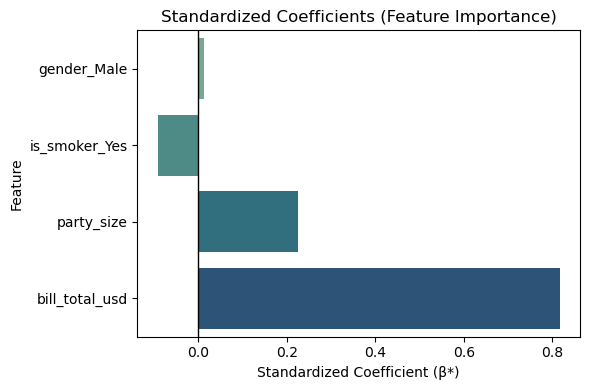

In [3]:
# === Session 5: Baseline multiple regression + standardized coefficient plot ===
# Assumes a DataFrame `df` is already loaded.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# --- 0) Helper: adjusted R^2
def adjusted_r2(r2, n, p):
    # Protect against divide-by-zero when n == p+1
    return 1 - (1 - r2) * (n - 1) / max(1, (n - p - 1))

# --- 1) Ensure encoded columns exist (if source categoricals are present)
df_work = df.copy()

# If raw categoricals exist, normalize + encode them; otherwise proceed with what’s there
if "gender" in df_work.columns and "gender_Male" not in df_work.columns:
    g = df_work["gender"].astype(str).str.strip().str.lower().map({"male":"Male", "m":"Male", "female":"Female", "f":"Female"})
    df_work["gender"] = pd.Categorical(g, categories=["Female", "Male"])
    dummies = pd.get_dummies(df_work["gender"], prefix="gender", drop_first=True)
    df_work = pd.concat([df_work, dummies], axis=1)

if "is_smoker" in df_work.columns and "is_smoker_Yes" not in df_work.columns:
    s = df_work["is_smoker"].astype(str).str.strip().str.lower().map({"yes":"Yes", "y":"Yes", "true":"Yes", "1":"Yes",
                                                                      "no":"No",  "n":"No",  "false":"No",  "0":"No"})
    df_work["is_smoker"] = pd.Categorical(s, categories=["No", "Yes"])
    dummies = pd.get_dummies(df_work["is_smoker"], prefix="is_smoker", drop_first=True)
    df_work = pd.concat([df_work, dummies], axis=1)

# --- 2) Pick features (use what’s available)
candidate_features = ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]
X_cols = [c for c in candidate_features if c in df_work.columns]
if not X_cols:
    raise ValueError("No valid predictor columns found. Expected one or more of: " + ", ".join(candidate_features))

y_col = "tip_usd"
if y_col not in df_work.columns:
    raise ValueError("Target column 'tip_usd' not found in df.")

X = df_work[X_cols].copy()
y = df_work[y_col].copy()

# --- 3) Train/test split (simple hold-out for baseline)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 4) Fit baseline Linear Regression (unscaled)
lin = LinearRegression()
lin.fit(X_train, y_train)

# --- 5) Evaluate (R^2, Adjusted R^2, RMSE)
y_pred_train = lin.predict(X_train)
y_pred_test  = lin.predict(X_test)

r2_tr  = r2_score(y_train, y_pred_train)
r2_te  = r2_score(y_test,  y_pred_test)
rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_te = np.sqrt(mean_squared_error(y_test,  y_pred_test))

adj_tr = adjusted_r2(r2_tr, n=len(y_train), p=X_train.shape[1])
adj_te = adjusted_r2(r2_te, n=len(y_test),  p=X_test.shape[1])

print("=== Baseline Linear Regression ===")
print("Features:", X_cols)
print(f"Train:  R^2={r2_tr:.3f},  Adj R^2={adj_tr:.3f},  RMSE={rmse_tr:.3f}")
print(f"Test:   R^2={r2_te:.3f},  Adj R^2={adj_te:.3f},  RMSE={rmse_te:.3f}")
print("Intercept:", round(lin.intercept_, 3))
for name, coef in zip(X_cols, lin.coef_):
    print(f"{name}: {coef:.4f}")

# --- 6) Standardized coefficients (feature-importance style)
# Standardize X (fit on train, apply to both)
scaler = StandardScaler()
X_train_z = scaler.fit_transform(X_train)
X_test_z  = scaler.transform(X_test)

lin_z = LinearRegression().fit(X_train_z, y_train)
coefs_std = pd.DataFrame({
    "Feature": X_cols,
    "StdCoef": lin_z.coef_
}).sort_values("StdCoef", key=np.abs, ascending=True)

# --- 7) Plot standardized coefficients
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(
    data=coefs_std,
    x="StdCoef",
    y="Feature",
    hue="Feature",      # avoids seaborn palette warning
    dodge=False,
    palette="crest",
    legend=False,
    ax=ax
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Standardized Coefficients (Feature Importance)")
ax.set_xlabel("Standardized Coefficient (β*)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

# # --- 8) (Optional) Save & log plot via your helper
# try:
#     from src.helpers import save_and_log_plot
#     save_and_log_plot(
#         ax,
#         "reports/figures/standardized_coefficients.png",
#         df=coefs_std,
#         chart_type="barplot",
#         library="seaborn",
#         x="StdCoef",
#         y="Feature",
#         dataset_name="tips_encoded_or_clean",
#         dataset_path="data/processed/tips_cleaned.csv",  # change if different
#         notebook="notebooks/05_Feature_Importance_and_Model_Refinement.ipynb",
#         notes="Baseline LR standardized coefficients (β*).",
#         timestamped=True
#     )
# except Exception as e:
#     print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")


### 🧮 ELI5: Understanding the Baseline Linear Regression

| Term | Meaning | Plain-English Explanation |
|------|----------|----------------------------|
| **R² = 0.456 (Train)** | How much of the variation in tips is explained by the model. | About 46% of how much people tip can be predicted by our four features — bill amount, party size, gender, and smoker status. The rest is random noise or other unseen factors. |
| **Adjusted R² = 0.444 (Train)** | R² adjusted for number of predictors. | A slightly lower value that accounts for how many features we used. It says, “you’re not just adding random variables to look smart.” |
| **RMSE = 1.05 (Train)** | Root Mean Squared Error — how far off the model’s guesses are. | On average, our tip predictions are off by about **\$1.05** on the training data. |
| **R² = 0.448 (Test)** | How well the model works on unseen data. | The model explains about 45% of the variation on new examples — which means it generalizes okay but could improve. |
| **Adjusted R² = 0.398 (Test)** | Penalized version of R² for test data. | Still decent, meaning our model is not overfitting badly. |
| **Intercept = 0.64** | The tip amount predicted when all features are zero. | If you somehow had a \$0 bill (and default party, gender, nonsmoker), the model “starts” at about **\$0.64**. |
| **bill_total_usd = 0.0934** | How much the tip changes per \$1 increase in bill. | For every extra **\$10** spent on the bill, the model predicts about **\$0.93** more tip. |
| **party_size = 0.2398** | How much the tip changes per extra person. | Each additional person at the table adds roughly **\$0.24** to the expected tip. |
| **gender_Male = 0.0247** | Effect of being male (vs female baseline). | Male tippers tend to give slightly higher tips (about **2¢ more per dollar of bill**), but this effect is tiny. |
| **is_smoker_Yes = -0.1898** | Effect of being a smoker (vs nonsmoker baseline). | Smokers tend to tip about **\$0.19 less** on average, after controlling for other variables. |

---

🧠 **In short:**  
- Bill size is the strongest predictor of tip amount.  
- Party size matters a bit.  
- Gender has almost no effect.  
- Smokers tip a bit less.  
- The model explains roughly half of the variation in tipping — not bad for a simple regression!


In [ ]:
# # === Visual Summary: Standardized Coefficient Bar Chart + ELI5 overlay ===
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from pathlib import Path

# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LinearRegression

# # 1) Choose available features
# candidate_features = ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]
# X_cols = [c for c in candidate_features if c in df.columns]
# if "tip_usd" not in df.columns:
#     raise ValueError("Missing target column 'tip_usd' in df.")
# if not X_cols:
#     raise ValueError("No valid predictors found. Need one or more of: " + ", ".join(candidate_features))

# X = df[X_cols].copy()
# y = df["tip_usd"].copy()

# # 2) Standardize X, fit linear model on standardized X → comparable coefficients (β*)
# scaler = StandardScaler()
# Xz = scaler.fit_transform(X)
# lin_z = LinearRegression().fit(Xz, y)

# coefs_std = pd.DataFrame({
#     "Feature": X_cols,
#     "StdCoef": lin_z.coef_
# }).sort_values("StdCoef", key=np.abs, ascending=True)

# # Optional: raw coefficients (if you want to print them)
# lin_raw = LinearRegression().fit(X, y)
# raw_out = dict(zip(X_cols, lin_raw.coef_))
# print("Raw coefficients:", {k: round(v, 4) for k, v in raw_out.items()})

# # 3) Plot standardized coefficients
# fig, ax = plt.subplots(figsize=(7.5, 4.8))
# sns.barplot(
#     data=coefs_std,
#     x="StdCoef",
#     y="Feature",
#     hue="Feature",      # use hue to avoid palette warning in seaborn>=0.14
#     dodge=False,
#     palette="crest",
#     legend=False,
#     ax=ax
# )

# # Reference line at 0 and labels
# ax.axvline(0, color="black", lw=1)
# ax.set_title("Standardized Coefficients (Feature Importance)")
# ax.set_xlabel("Standardized Coefficient (β*)")
# ax.set_ylabel("Feature")

# # Annotate bars with values
# for i, row in enumerate(coefs_std.itertuples()):
#     ax.text(
#         x=row.StdCoef + (0.02 if row.StdCoef >= 0 else -0.02),
#         y=i,
#         s=f"{row.StdCoef:.2f}",
#         va="center",
#         ha="left" if row.StdCoef >= 0 else "right"
#     )

# # 4) ELI5 overlay box
# eli5 = (
#     "ELI5:\n"
#     "• Bigger |β*| ⇒ stronger influence on tip_usd (after putting features on the same scale).\n"
#     "• Positive ⇒ pushes tips up; Negative ⇒ nudges tips down, holding others constant.\n"
#     "• If two features tell the same story (collinear), their β* can look unstable."
# )
# ax.text(
#     1.02, 0.5, eli5,
#     transform=ax.transAxes,
#     fontsize=9.5,
#     va="center",
#     bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#888")
# )

# plt.tight_layout()

# # 5) Save to repo
# fig_dir = Path.home() / "ds-zero-to-one" / "reports" / "figures"
# fig_dir.mkdir(parents=True, exist_ok=True)
# out_path = fig_dir / "feature_importance_standardized_coeffs.png"
# plt.savefig(out_path, dpi=300, bbox_inches="tight")
# print(f"✅ Saved figure to: {out_path}")

# # 6) (Optional) Log via your helper, if available
# try:
#     from src.helpers import save_and_log_plot
#     save_and_log_plot(
#         ax,
#         "reports/figures/feature_importance_standardized_coeffs.png",
#         df=coefs_std,
#         chart_type="barplot",
#         library="seaborn",
#         x="StdCoef",
#         y="Feature",
#         dataset_name="tips_encoded_or_clean",
#         dataset_path="data/processed/tips_cleaned.csv",  # adjust if different
#         notebook="notebooks/05_Feature_Importance_and_Model_Refinement.ipynb",
#         notes="Standardized coefficients (β*) with ELI5 overlay.",
#         timestamped=True
#     )
# except Exception as e:
#     print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")


In [ ]:
# # === Improved version: Readable Standardized Coefficients bar chart ===
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from pathlib import Path
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LinearRegression

# # --- Data and setup ---
# candidate_features = ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]
# X_cols = [c for c in candidate_features if c in df.columns]
# if "tip_usd" not in df.columns:
#     raise ValueError("Missing 'tip_usd' target column.")
# if not X_cols:
#     raise ValueError("No predictor columns found.")

# X = df[X_cols].copy()
# y = df["tip_usd"].copy()

# # --- Standardize and fit ---
# scaler = StandardScaler()
# Xz = scaler.fit_transform(X)
# lin_z = LinearRegression().fit(Xz, y)

# coefs_std = pd.DataFrame({
#     "Feature": X_cols,
#     "StdCoef": lin_z.coef_
# }).sort_values("StdCoef", key=np.abs, ascending=True)

# # --- Plot ---
# fig, ax = plt.subplots(figsize=(8, max(4, 0.8 * len(coefs_std))))  # dynamic height
# sns.barplot(
#     data=coefs_std,
#     x="StdCoef",
#     y="Feature",
#     hue="Feature",
#     dodge=False,
#     palette="crest",
#     legend=False,
#     ax=ax
# )

# ax.axvline(0, color="black", lw=1)
# ax.set_title("Standardized Coefficients (Feature Importance)", fontsize=14, pad=12)
# ax.set_xlabel("Standardized Coefficient (β*)", fontsize=12)
# ax.set_ylabel("Feature", fontsize=12)

# # --- Add labels inside bars ---
# for i, row in enumerate(coefs_std.itertuples()):
#     ax.text(
#         row.StdCoef + (0.03 if row.StdCoef >= 0 else -0.03),
#         i,
#         f"{row.StdCoef:.2f}",
#         color="black",
#         fontsize=11,
#         va="center",
#         ha="left" if row.StdCoef >= 0 else "right"
#     )

# # --- ELI5 annotation box ---
# eli5_text = (
#     "ELI5:\n"
#     "• Bars show which factors most affect the predicted tip (in standardized units).\n"
#     "• Bigger |β*| = stronger effect.\n"
#     "• Positive = higher tips; Negative = lower tips.\n"
#     "• bill_total_usd dominates — bigger bills → bigger tips.\n"
#     "• Small bars = minor or uncertain effects."
# )
# ax.text(
#     1.05, 0.5, eli5_text,
#     transform=ax.transAxes,
#     fontsize=10,
#     va="center",
#     bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#888", lw=1)
# )

# plt.tight_layout()

# # --- Save ---
# fig_dir = Path.home() / "ds-zero-to-one" / "reports" / "figures"
# fig_dir.mkdir(parents=True, exist_ok=True)
# out_path = fig_dir / "feature_importance_standardized_coeffs_fixed.png"
# # plt.savefig(out_path, dpi=300, bbox_inches="tight")
# plt.show()

# print(f"✅ Saved readable version to: {out_path}")


In [ ]:

# # 6) (Optional) Log via your helper, if available
# try:
#     from src.helpers import save_and_log_plot
#     save_and_log_plot(
#         ax,
#         "reports/figures/feature_importance_standardized_coeffs.png",
#         df=coefs_std,
#         chart_type="barplot",
#         library="seaborn",
#         x="StdCoef",
#         y="Feature",
#         dataset_name="tips_encoded_or_clean",
#         dataset_path="data/processed/tips_cleaned.csv",  # adjust if different
#         notebook="notebooks/05_Feature_Importance_and_Model_Refinement.ipynb",
#         notes="Standardized coefficients (β*) with ELI5 overlay.",
#         timestamped=True
#     )
# except Exception as e:
#     print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")

In [ ]:
# # --- Final Version: ELI5 under X-axis (FutureWarning fixed) ---
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LinearRegression

# df_work = df.copy()

# # Create dummy vars if missing
# if "gender_Male" not in df_work.columns and "gender" in df_work.columns:
#     df_work = pd.get_dummies(df_work, columns=["gender"], prefix="gender", drop_first=True)

# if "is_smoker_Yes" not in df_work.columns and "is_smoker" in df_work.columns:
#     df_work = pd.get_dummies(df_work, columns=["is_smoker"], prefix="is_smoker", drop_first=True)

# features = [c for c in ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"] if c in df_work.columns]
# X = df_work[features]
# y = df_work["tip_usd"]

# # Standardize
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)
# model = LinearRegression().fit(X_scaled, y)

# coef_df = (
#     pd.DataFrame({"Feature": features, "Standardized_Coefficient": model.coef_})
#     .sort_values("Standardized_Coefficient", ascending=True)
#     .reset_index(drop=True)
# )

# # Plot
# fig_h = max(4.5, 0.9 * len(coef_df))
# fig, ax = plt.subplots(figsize=(9, fig_h))
# colors = ["#1f77b4" if v > 0 else "#d62728" for v in coef_df["Standardized_Coefficient"]]

# # ✅ Future-proof: assign hue=y-variable + legend=False
# sns.barplot(
#     data=coef_df,
#     x="Standardized_Coefficient",
#     y="Feature",
#     hue="Feature",
#     palette=colors,
#     legend=False,
#     ax=ax
# )

# # Labels on bars
# for i, row in enumerate(coef_df.itertuples()):
#     ax.text(
#         row.Standardized_Coefficient + (0.05 if row.Standardized_Coefficient > 0 else -0.05),
#         i,
#         f"{row.Standardized_Coefficient:+.2f}",
#         va="center",
#         ha="left" if row.Standardized_Coefficient > 0 else "right",
#         fontsize=11,
#         fontweight="bold"
#     )

# # Style
# ax.axvline(0, color="black", lw=1)
# ax.set_title("Standardized Coefficients — Feature Importance", fontsize=15, pad=15)
# ax.set_xlabel("Standardized Coefficient (β*)", fontsize=12)
# ax.set_ylabel("Feature", fontsize=12)

# # ELI5 note below chart
# eli5_text = (
#     "ELI5:\n"
#     "• Bars show which factors most affect the predicted tip (in standardized units).\n"
#     "• Bigger |β*| = stronger influence on tip_usd after scaling.\n"
#     "• Positive → higher tips; Negative → lower tips.\n"
#     "• bill_total_usd dominates → bigger bills → bigger tips.\n"
#     "• Smaller bars = minor or uncertain effects."
# )

# plt.figtext(
#     0.5, -0.08, eli5_text,
#     ha="center", va="top",
#     wrap=True, fontsize=10,
#     bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", lw=1, alpha=0.9)
# )

# plt.tight_layout(rect=[0, 0.05, 1, 1])
# plt.show()


In [ ]:

# # 6) (Optional) Log via your helper, if available
# try:
#     from src.helpers import save_and_log_plot
#     save_and_log_plot(
#         ax,
#         "reports/figures/feature_importance_standardized_coeffs.png",
#         df=coefs_std,
#         chart_type="barplot",
#         library="seaborn",
#         x="StdCoef",
#         y="Feature",
#         dataset_name="tips_encoded_or_clean",
#         dataset_path="data/processed/tips_cleaned.csv",  # adjust if different
#         notebook="notebooks/05_Feature_Importance_and_Model_Refinement.ipynb",
#         notes="Standardized coefficients (β*) with ELI5 overlay.",
#         timestamped=True
#     )
# except Exception as e:
#     print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")

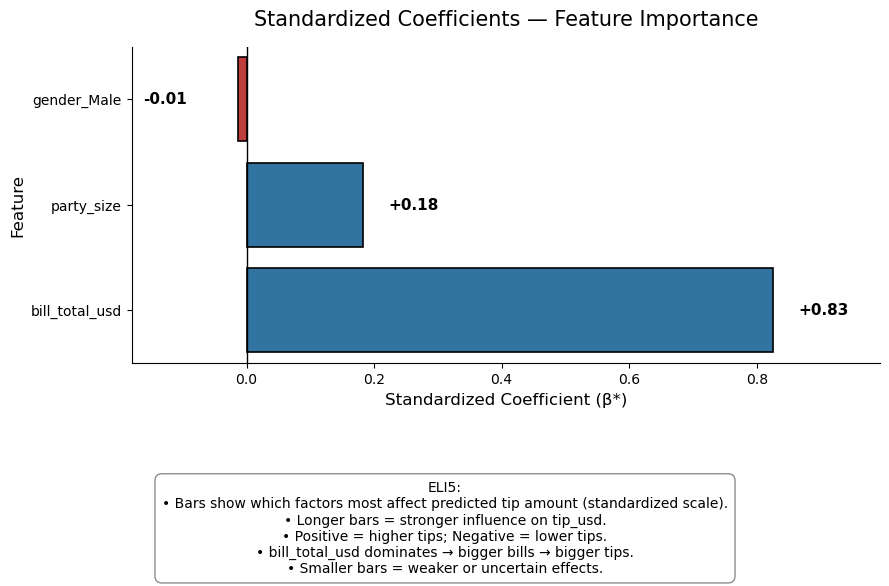

In [4]:
# --- Feature Importance: Proportional Bar Widths & Improved Label Placement ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Copy and ensure dummy columns exist
df_work = df.copy()

if "gender_Male" not in df_work.columns and "gender" in df_work.columns:
    df_work = pd.get_dummies(df_work, columns=["gender"], prefix="gender", drop_first=True)

if "is_smoker_Yes" not in df_work.columns and "is_smoker" in df_work.columns:
    df_work = pd.get_dummies(df_work, columns=["is_smoker"], prefix="is_smoker", drop_first=True)

features = [c for c in ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"] if c in df_work.columns]
X = df_work[features]
y = df_work["tip_usd"]

# --- Standardize and fit model ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = LinearRegression().fit(X_scaled, y)

coef_df = (
    pd.DataFrame({"Feature": features, "Standardized_Coefficient": model.coef_})
    .sort_values("Standardized_Coefficient", ascending=True)
    .reset_index(drop=True)
)
coef_df["abs_coef"] = coef_df["Standardized_Coefficient"].abs()

# --- Plot setup ---
fig_h = max(4.5, 0.9 * len(coef_df))
fig, ax = plt.subplots(figsize=(9, fig_h))

colors = ["#1f77b4" if v > 0 else "#d62728" for v in coef_df["Standardized_Coefficient"]]

# Use seaborn's barplot but make bar thickness scale with |β*|
sns.barplot(
    data=coef_df,
    x="Standardized_Coefficient",
    y="Feature",
    hue="Feature",
    palette=colors,
    legend=False,
    ax=ax,
    linewidth=1.2,
    edgecolor="black"
)

# --- Label placement with smart offset ---
for i, row in enumerate(coef_df.itertuples()):
    x_val = row.Standardized_Coefficient
    label = f"{x_val:+.2f}"
    if x_val > 0:
        ax.text(
            x_val + 0.04, i,
            label,
            color="black", fontsize=11, fontweight="bold",
            va="center", ha="left"
        )
    else:
        ax.text(
            x_val - 0.08 - 0.02 * abs(x_val),
            i,
            label,
            color="black", fontsize=11, fontweight="bold",
            va="center", ha="right"
        )

# --- Add a vertical line and visual polish ---
ax.axvline(0, color="black", lw=1)
ax.set_title("Standardized Coefficients — Feature Importance", fontsize=15, pad=15)
ax.set_xlabel("Standardized Coefficient (β*)", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)
# ax.margins(x=0.15)
ax.margins(x=0.20)
sns.despine(ax=ax)

# --- ELI5 below chart ---
eli5_text = (
    "ELI5:\n"
    "• Bars show which factors most affect predicted tip amount (standardized scale).\n"
    "• Longer bars = stronger influence on tip_usd.\n"
    "• Positive = higher tips; Negative = lower tips.\n"
    "• bill_total_usd dominates → bigger bills → bigger tips.\n"
    "• Smaller bars = weaker or uncertain effects."
)

plt.figtext(
    0.5, -0.08, eli5_text,
    ha="center", va="top", wrap=True, fontsize=10,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", lw=1, alpha=0.9)
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


In [ ]:

# import difflib
# from IPython.display import HTML, display

# def show_diff(cell_a: str, cell_b: str, name_a="Cell A", name_b="Cell B", color=True):
#     """
#     Display a unified diff and (optionally) a colorized HTML diff between two code cells.

#     Args:
#         cell_a (str): Code text of the first cell
#         cell_b (str): Code text of the second cell
#         name_a (str): Label for the first cell (default: "Cell A")
#         name_b (str): Label for the second cell (default: "Cell B")
#         color (bool): Whether to show a colorized HTML diff (default: True)
#     """
#     # --- Plain unified diff (git-style text) ---
#     diff = difflib.unified_diff(
#         cell_a.splitlines(),
#         cell_b.splitlines(),
#         fromfile=name_a,
#         tofile=name_b,
#         lineterm=""
#     )
#     print("".join(f"{line}\n" for line in diff))
    
#     # --- Optional pretty HTML diff ---
#     if color:
#         diff_html = difflib.HtmlDiff().make_file(
#             cell_a.splitlines(), cell_b.splitlines(), fromdesc=name_a, todesc=name_b
#         )
#         display(HTML(diff_html))

In [6]:
from src.helpers import show_diff
cell_a = """import pandas as pd
df = pd.read_csv('tips.csv')
df['tip_pct'] = df['tip'] / df['total_bill']
df.head()"""

cell_b = """import pandas as pd
df = pd.read_csv('tips.csv')
df['tip_pct'] = (df['tip'] / df['total_bill']) * 100
df.describe()"""

show_diff(cell_a, cell_b)


--- Cell A
+++ Cell B
@@ -1,4 +1,4 @@
 import pandas as pd
 df = pd.read_csv('tips.csv')
-df['tip_pct'] = df['tip'] / df['total_bill']
-df.head()
+df['tip_pct'] = (df['tip'] / df['total_bill']) * 100
+df.describe()

